In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.special import logsumexp
from matplotlib.collections import LineCollection
sys.path.insert(0, "../src")
from instance_generator import InstanceGenerator

In [3]:
# Initialize generator
gen = InstanceGenerator(
    farmers_full_df_path="../data/farmers.csv",
    farmers_14_df_path="../data/farmers_2.csv",
    ints_df_path="../data/ints.csv",
    graph_path="../data/graph_0-14960_00_new.pickle"
)

In [ ]:
gen.gen_ints(1, 340, set_type="high")
# gen.ints['elated_bardeen']['type'] = [REDACTED]

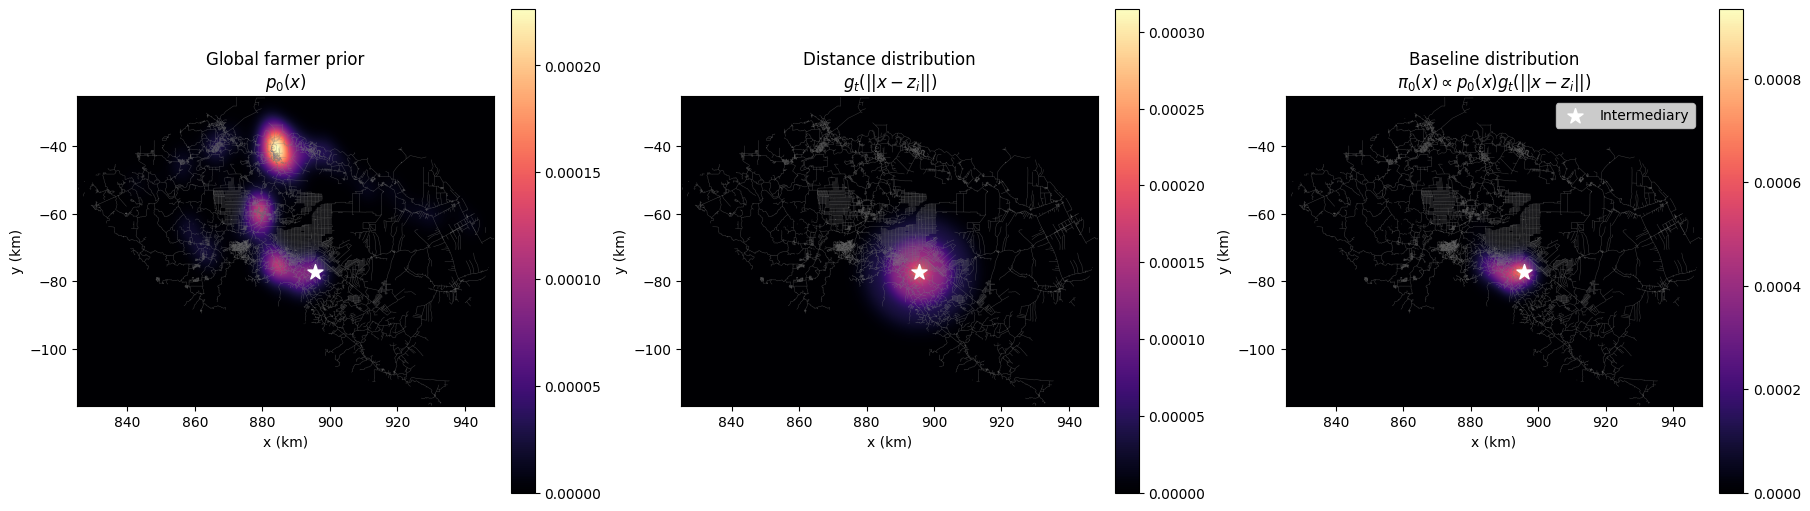

In [5]:
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Pick one empirical intermediary as the example
# ------------------------------------------------------------

int_xy = gen.ints['elated_bardeen']['xy']

# ------------------------------------------------------------
# Build the three distributions
# ------------------------------------------------------------
grid_points = gen.grid_coords.T

x_coords = np.unique(gen.grid_coords[0])
y_coords = np.unique(gen.grid_coords[1])
nx, ny = len(x_coords), len(y_coords)

# 1. Global farmer prior
p_global = gen.p_spatial.copy()

# 2. Distance distribution centered at intermediary
dists = np.linalg.norm(grid_points - int_xy, axis=1)
p_dist = gen.gamma_lookups[gen.ints['elated_bardeen']['type']](dists)

# 3. Baseline distribution:
#    p_base(x) ∝ p_global(x) * p_dist(||x - int_xy||)
eps = 1e-20
log_p_base = np.log(p_global + eps) + np.log(p_dist + eps)
log_p_base -= logsumexp(log_p_base)
p_base = np.exp(log_p_base)

# ------------------------------------------------------------
# Reshape for plotting
# ------------------------------------------------------------
Z_global = p_global.reshape(nx, ny)
Z_dist = p_dist.reshape(nx, ny)
Z_base = p_base.reshape(nx, ny)

# Optional: normalize p_dist just for comparable visualization
Z_dist_viz = Z_dist / (Z_dist.sum() + eps)

# ------------------------------------------------------------
# Build road lines
# ------------------------------------------------------------
road_lines = []

for u, v, data in gen.G_proj.edges(data=True):
    if "geometry" in data:
        xs, ys = data["geometry"].xy
        road_lines.append(list(zip(xs, ys)))
    else:
        u_node = gen.G_proj.nodes[u]
        v_node = gen.G_proj.nodes[v]
        road_lines.append([
            (u_node["x"], u_node["y"]),
            (v_node["x"], v_node["y"]),
        ])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
KM = 1000.0

x_coords_km = x_coords / KM
y_coords_km = y_coords / KM
int_xy_km = int_xy / KM

road_lines_km = [
    [(x / KM, y / KM) for x, y in line]
    for line in road_lines
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

panels = [
    ("Global farmer prior\n$p_0(x)$", Z_global),
    ("Distance distribution\n$g_t(||x - z_i||)$", Z_dist_viz),
    ("Baseline distribution\n$\\pi_0(x) \\propto p_0(x)g_t(||x-z_i||)$", Z_base),
]

for ax, (title, Z) in zip(axes, panels):
    im = ax.imshow(
        Z.T,
        origin="lower",
        extent=[
            x_coords_km.min(),
            x_coords_km.max(),
            y_coords_km.min(),
            y_coords_km.max(),
        ],
        cmap="magma",
        aspect="equal",
        zorder=0,
    )

    ax.add_collection(
        LineCollection(
            road_lines_km,
            colors="gray",
            linewidths=0.35,
            alpha=0.25,
            zorder=1,
        )
    )

    ax.scatter(
        int_xy_km[0],
        int_xy_km[1],
        marker="*",
        s=130,
        c="white",
        edgecolors="white",
        linewidths=1,
        zorder=5,
        label="Intermediary",
    )

    ax.set_title(title)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_xlim(x_coords_km.min(), x_coords_km.max())
    ax.set_ylim(y_coords_km.min(), y_coords_km.max())

    fig.colorbar(im, ax=ax, pad=0.04)

axes[-1].legend(loc="upper right")
plt.savefig("../figures/ig_kde_vis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
gen.gen_ints(1, 340, set_type="high")
# gen.ints['elated_bardeen']['type'] = [REDACTED]

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.special import logsumexp
from matplotlib.colors import PowerNorm

# ------------------------------------------------------------
# Choose intermediary and sampling parameters
# ------------------------------------------------------------
int_id = "elated_bardeen"

int_xy = gen.ints[int_id]["xy"]
int_type = gen.ints[int_id]["type"]

n_farmers_to_show = 3
sigma = gen.sigmas.get(int_type, 5000)  # or set manually, e.g. sigma = 5000
seed = 123
rng = np.random.default_rng(seed)

KM = 1000.0
eps = 1e-20

# ------------------------------------------------------------
# Grid setup
# ------------------------------------------------------------
grid_points = gen.grid_coords.T

x_coords = np.unique(gen.grid_coords[0])
y_coords = np.unique(gen.grid_coords[1])
nx, ny = len(x_coords), len(y_coords)

x_coords_km = x_coords / KM
y_coords_km = y_coords / KM
int_xy_km = int_xy / KM

# ------------------------------------------------------------
# Build baseline distribution
# ------------------------------------------------------------
p_global = gen.p_spatial.copy()

dists = np.linalg.norm(grid_points - int_xy, axis=1)
p_dist = gen.gamma_lookups[int_type](dists)

log_p_base = np.log(p_global + eps) + np.log(p_dist + eps)
log_p_base -= logsumexp(log_p_base)

# ------------------------------------------------------------
# Build road lines in km
# ------------------------------------------------------------
road_lines = []

for u, v, data in gen.G_proj.edges(data=True):
    if "geometry" in data:
        xs, ys = data["geometry"].xy
        xs = np.asarray(xs)
        ys = np.asarray(ys)
        road_lines.append(list(zip(xs / KM, ys / KM)))
    else:
        u_node = gen.G_proj.nodes[u]
        v_node = gen.G_proj.nodes[v]
        road_lines.append([
            (u_node["x"] / KM, u_node["y"] / KM),
            (v_node["x"] / KM, v_node["y"] / KM),
        ])

# ------------------------------------------------------------
# Sequential farmer sampling, storing each conditional distribution
# ------------------------------------------------------------
sampled_xys = []
conditional_distributions = []
local_fields = []

sigma_sq_2 = 2 * sigma**2
acc_exp_kernels = np.zeros(len(grid_points))

for k in range(n_farmers_to_show):
    if k == 0:
        log_p_cond = log_p_base.copy()
        local_factor = np.ones(len(grid_points))
    else:
        local_factor = acc_exp_kernels / k
        log_local_factor = np.log(local_factor + eps)
        log_p_cond = log_p_base + log_local_factor
        log_p_cond -= logsumexp(log_p_cond)

    p_cond = np.exp(log_p_cond)

    # Numerical safety fallback, same spirit as gen_farmers
    if np.isnan(p_cond).any() or p_cond.sum() == 0:
        p_cond = gen.p_spatial.copy()
        p_cond = p_cond / p_cond.sum()

    conditional_distributions.append(p_cond.copy())
    local_fields.append(local_factor.copy())

    sampled_idx = rng.choice(len(p_cond), p=p_cond / p_cond.sum())
    sampled_xy = gen.grid_coords[:, sampled_idx]
    sampled_xys.append(sampled_xy)

    # Update clustering kernel for the next farmer
    new_dist_sq = np.sum((grid_points - sampled_xy) ** 2, axis=1)
    acc_exp_kernels += np.exp(-new_dist_sq / sigma_sq_2)

sampled_xys = np.array(sampled_xys)
sampled_xys_km = sampled_xys / KM

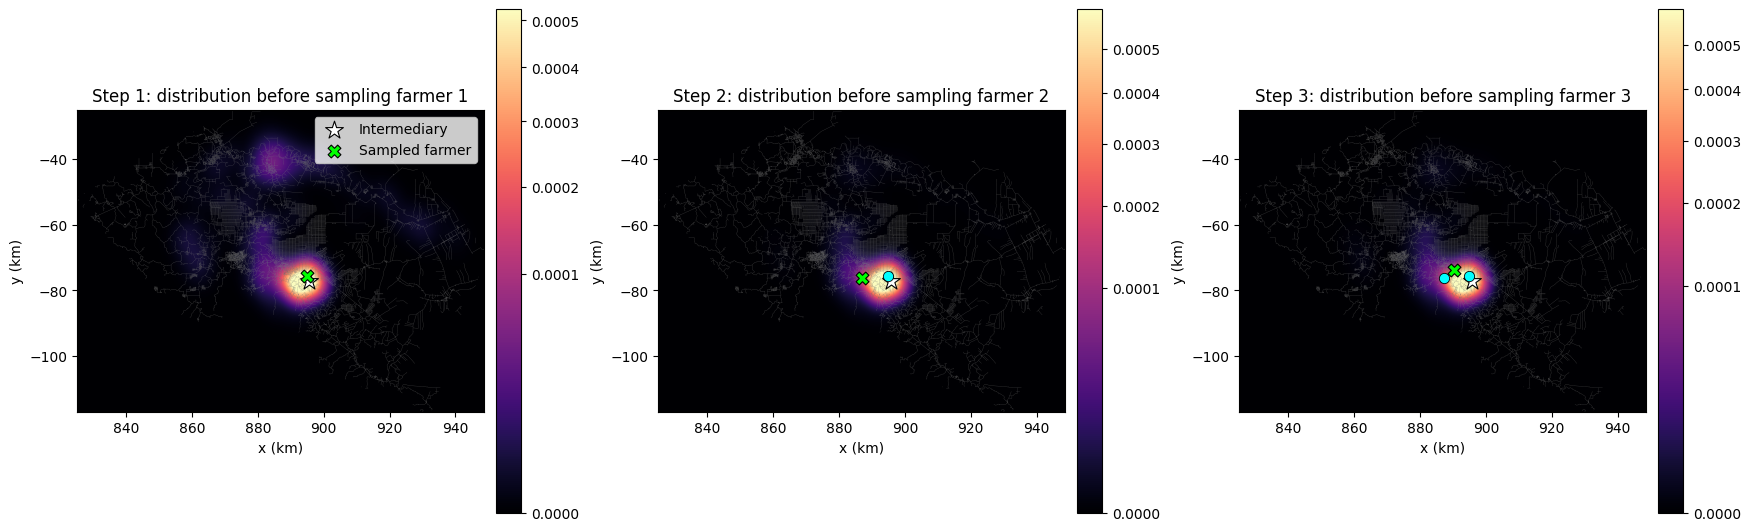

In [9]:
# ------------------------------------------------------------
# Plot conditional distribution before each farmer is sampled
# ------------------------------------------------------------
ncols = 3
nrows = int(np.ceil(n_farmers_to_show / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.8 * ncols, 5.2 * nrows),
    squeeze=False,
    constrained_layout=True,
)

for k in range(n_farmers_to_show):
    ax = axes[k // ncols, k % ncols]

    Z = conditional_distributions[k].reshape(nx, ny)

    # Accent colors
    vmax = np.percentile(Z, 99.7)
    norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)

    im = ax.imshow(
        Z.T,
        origin="lower",
        extent=[
            x_coords_km.min(),
            x_coords_km.max(),
            y_coords_km.min(),
            y_coords_km.max(),
        ],
        cmap="magma",
        norm=norm,
        aspect="equal",
        zorder=0,
    )

    ax.add_collection(
        LineCollection(
            road_lines,
            colors="gray",
            linewidths=0.3,
            alpha=0.20,
            zorder=1,
        )
    )

    # Intermediary
    ax.scatter(
        int_xy_km[0],
        int_xy_km[1],
        marker="*",
        s=180,
        c="white",
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
        label="Intermediary" if k == 0 else None,
    )

    # Previously sampled farmers
    if k > 0:
        ax.scatter(
            sampled_xys_km[:k, 0],
            sampled_xys_km[:k, 1],
            s=55,
            c="cyan",
            edgecolors="black",
            linewidths=0.6,
            zorder=6,
            label="Previous farmers" if k == 1 else None,
        )

    # Current sampled farmer
    ax.scatter(
        sampled_xys_km[k, 0],
        sampled_xys_km[k, 1],
        marker="X",
        s=85,
        c="lime",
        edgecolors="black",
        linewidths=0.8,
        zorder=7,
        label="Sampled farmer" if k == 0 else None,
    )

    ax.set_title(f"Step {k + 1}: distribution before sampling farmer {k + 1}")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_xlim(x_coords_km.min(), x_coords_km.max())
    ax.set_ylim(y_coords_km.min(), y_coords_km.max())

    fig.colorbar(im, ax=ax, pad=0.03)

# Hide unused axes
for k in range(n_farmers_to_show, nrows * ncols):
    axes[k // ncols, k % ncols].axis("off")

axes[0, 0].legend(loc="upper right")
plt.savefig("../figures/eda_dist_kde.png", dpi=300, bbox_inches="tight")
plt.show()

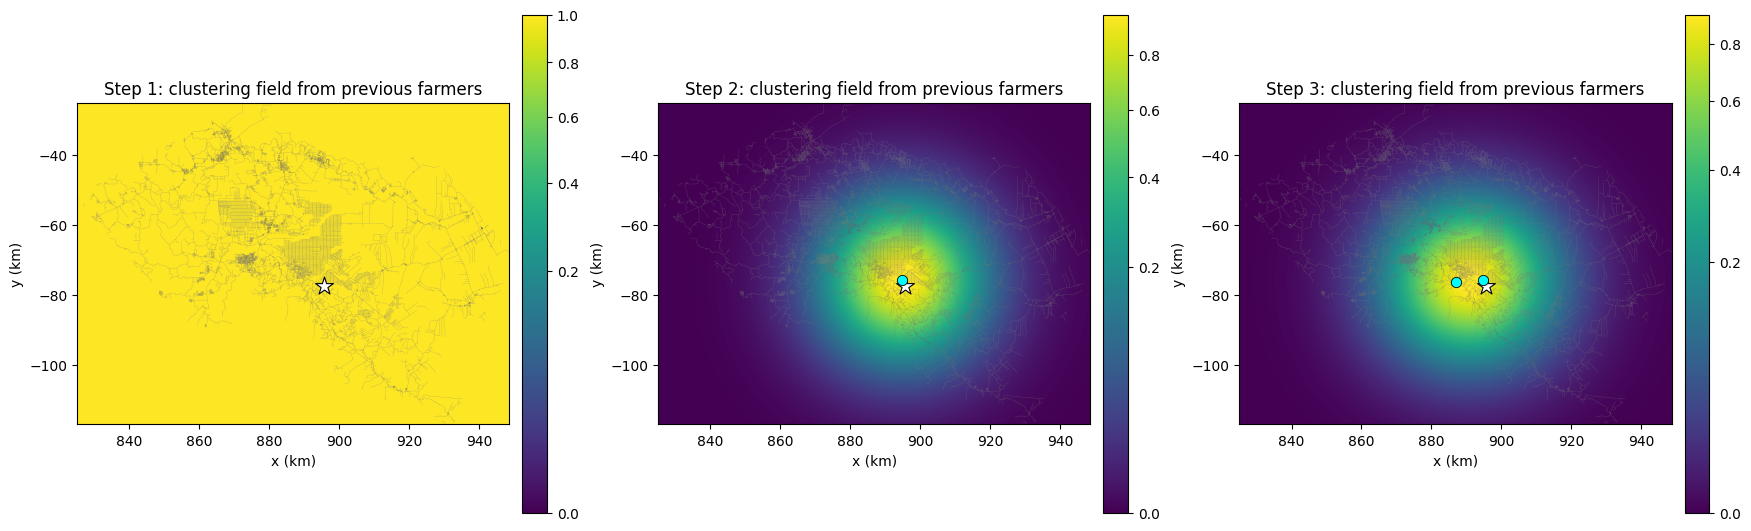

In [142]:
# ------------------------------------------------------------
# Plot local clustering field only
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.8 * ncols, 5.2 * nrows),
    squeeze=False,
    constrained_layout=True,
)

for k in range(n_farmers_to_show):
    ax = axes[k // ncols, k % ncols]

    Z = local_fields[k].reshape(nx, ny)

    if k == 0:
        # First farmer has no clustering influence yet
        Z = np.ones_like(Z)

    vmax = np.percentile(Z, 99.7)
    norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)

    im = ax.imshow(
        Z.T,
        origin="lower",
        extent=[
            x_coords_km.min(),
            x_coords_km.max(),
            y_coords_km.min(),
            y_coords_km.max(),
        ],
        cmap="viridis",
        norm=norm,
        aspect="equal",
        zorder=0,
    )

    ax.add_collection(
        LineCollection(
            road_lines,
            colors="gray",
            linewidths=0.3,
            alpha=0.20,
            zorder=1,
        )
    )

    ax.scatter(
        int_xy_km[0],
        int_xy_km[1],
        marker="*",
        s=180,
        c="white",
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
    )

    if k > 0:
        ax.scatter(
            sampled_xys_km[:k, 0],
            sampled_xys_km[:k, 1],
            s=55,
            c="cyan",
            edgecolors="black",
            linewidths=0.6,
            zorder=6,
        )

    ax.set_title(f"Step {k + 1}: clustering field from previous farmers")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_xlim(x_coords_km.min(), x_coords_km.max())
    ax.set_ylim(y_coords_km.min(), y_coords_km.max())

    fig.colorbar(im, ax=ax, pad=0.03)

for k in range(n_farmers_to_show, nrows * ncols):
    axes[k // ncols, k % ncols].axis("off")

plt.show()